In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [18]:
def getInfo(mfile):
    m_read = open(mfile,'r')
    lines = m_read.readlines()
    cols = []
    for line in lines:
        if("# column" in line):
            line = line.replace(":"," ")
            tokens = line.split()
            cols.append(tokens[3])
        if("# NX" in line):
            tokens = line.split()
            NX = int(tokens[3])
        if("# NY" in line):
            tokens = line.split()
            NY = int(tokens[3])
    nskip = find_correct_skip_rows(mfile)
    return NX, NY, cols, nskip+2

def find_correct_skip_rows(file_path, max_skip=200):
    """
    Attempts to find the correct number of rows to skip when opening a CSV with pandas.
    
    :param file_path: Path to the CSV file.
    :param max_skip: Maximum number of rows to try skipping.
    :return: A tuple containing the DataFrame and the correct skiprows value.
    """
    nskip = 6  # Start with no skipped rows
    
    while nskip <= max_skip:
        try:
            df = pd.read_csv(file_path, sep=r'\s+', skiprows=nskip)
            # Check if column names are valid
            if all(isinstance(col, str) for col in df.columns):
                #print(f"Successfully loaded with skiprows={nskip}")
                return nskip
        except Exception as e:
            pass
        
        nskip += 1  # Increment and try again

    #raise ValueError(f"Could not determine the correct skiprows value within {max_skip} rows.")
    print(f"Could not determine the correct skiprows value within {max_skip} rows.")
    return -1 
    

['node-number', 'x-distance', 'y-distance', 'Uraninite']


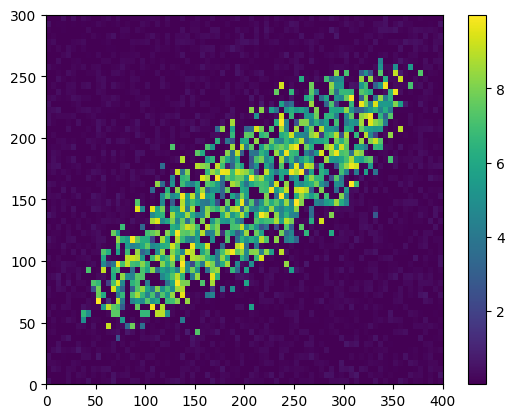

In [30]:
file = "U_dist.dat"
NX, NY, colnames, nskip = getInfo(file)
print(colnames)
df = pd.read_csv(file,sep=r'\s+',header=None,skiprows=nskip)
df.columns = colnames
values = df["Uraninite"].to_numpy()
U = np.zeros((NX,NY))
U = values.reshape(NY,NX)

XMIN, XMAX = df['x-distance'].min(), df['x-distance'].max()
YMIN, YMAX = df['y-distance'].min(), df['y-distance'].max()

xgrid = np.linspace(XMIN,XMAX,NX)
ygrid = np.linspace(YMIN,YMAX,NY)

plt.pcolormesh(xgrid,ygrid,U)
plt.colorbar()

In [26]:
print(xgrid)

[  2.5   7.5  12.5  17.5  22.5  27.5  32.5  37.5  42.5  47.5  52.5  57.5
  62.5  67.5  72.5  77.5  82.5  87.5  92.5  97.5 102.5 107.5 112.5 117.5
 122.5 127.5 132.5 137.5 142.5 147.5 152.5 157.5 162.5 167.5 172.5 177.5
 182.5 187.5 192.5 197.5 202.5 207.5 212.5 217.5 222.5 227.5 232.5 237.5
 242.5 247.5 252.5 257.5 262.5 267.5 272.5 277.5 282.5 287.5 292.5 297.5
 302.5 307.5 312.5 317.5 322.5 327.5 332.5 337.5 342.5 347.5 352.5 357.5
 362.5 367.5 372.5 377.5 382.5 387.5 392.5 397.5]
